This problem involves the Boston data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.

(a) For each predictor, ft a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically signifcant association between the predictor
and the response? Create some plots to back up your assertions.

(b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis H0 : βj = 0?

(c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefcients
from (a) on the x-axis, and the multiple regression coefcients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefcient in a simple linear regression model is shown on the x-axis, and its coefcient estimate
in the multiple linear regression model is shown on the y-axis.

(d) Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, ft a model of the form
Y = β0 + β1X + β2X2 + β3X3 + ".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.anova import anova_lm
from ISLP.models import summarize, poly
from ISLP.models import ModelSpec as MS
from ISLP import load_data


In [2]:


df = load_data("Boston")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
lstat      float64
medv       float64
dtype: object

             coef  std err       t  P>|t|
intercept  4.4537    0.417  10.675    0.0
zn        -0.0739    0.016  -4.594    0.0

             coef  std err      t  P>|t|
intercept -2.0637    0.667 -3.093  0.002
indus      0.5098    0.051  9.991  0.000

             coef  std err      t  P>|t|
intercept  3.7444    0.396  9.453  0.000
chas      -1.8928    1.506 -1.257  0.209

              coef  std err       t  P>|t|
intercept -13.7199    1.699  -8.073    0.0
nox        31.2485    2.999  10.419    0.0

              coef  std err      t  P>|t|
intercept  20.4818    3.364  6.088    0.0
rm         -2.6841    0.532 -5.045    0.0

             coef  std err      t  P>|t|
intercept -3.7779    0.944 -4.002    0.0
age        0.1078    0.013  8.463    0.0

             coef  std err       t  P>|t|
intercept  9.4993    0.730  13.006    0.0
dis       -1.5509    0.168  -9.213    0.0

             coef  std err       t  P>|t|
intercept -2.2872    0.443  -5.157    0.0
rad        0.6179    0.034  17.99

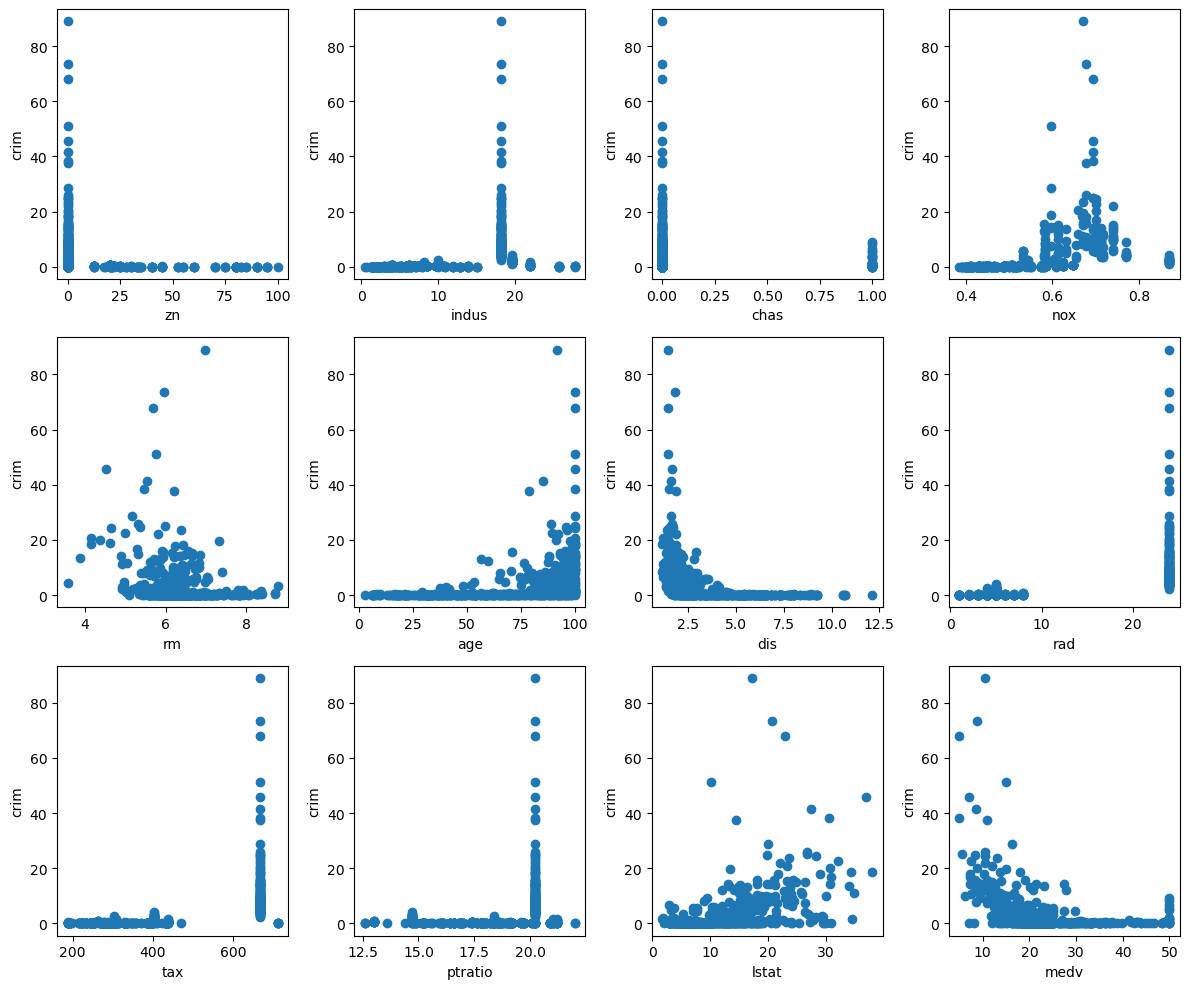

In [4]:
y=df["crim"]
predictors = df.columns.drop("crim")


fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(12,10))
ax = ax.flatten()

arr = []
for i, predictor in enumerate(predictors):
    X = MS([predictor]).fit_transform(df)
    results = sm.OLS(y, X).fit()
    arr.append(results.params.iloc[1])
    print(summarize(results))
    
    # Plot on the corresponding subplot
    ax[i].scatter(df[predictor], y)
    ax[i].set_xlabel(predictor)
    ax[i].set_ylabel('crim')
    print()

plt.tight_layout()
plt.show()

looking on the result we see that only column "chas" does not make sens (P value is > 0.05) 

(b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis H0 : βj = 0?

(c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefcients
from (a) on the x-axis, and the multiple regression coefcients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefcient in a simple linear regression model is shown on the x-axis, and its coefcient estimate
in the multiple linear regression model is shown on the y-axis.

In [15]:

X = MS(predictors).fit_transform(df)
res = sm.OLS(y, X).fit()

summarize(res)

,coef,std err,t,P>|t|
intercept,13.7784,7.082,1.946,0.052
zn,0.0457,0.019,2.433,0.015
indus,-0.0584,0.084,-0.698,0.486
chas,-0.8254,1.183,-0.697,0.486
nox,-9.9576,5.290,-1.882,0.060
rm,0.6289,0.607,1.036,0.301
age,-0.0008,0.018,-0.047,0.962
dis,-1.0122,0.282,-3.584,0.000
rad,0.6125,0.088,6.997,0.000
tax,-0.0038,0.005,-0.730,0.466


we can reject null hypothesis in columns dis,rad,medv.
( P value tell us how relevant/important is the predictor)

c)

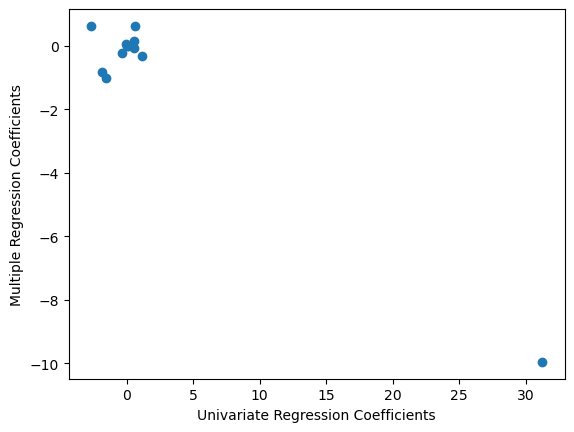

In [32]:
plt.scatter(arr, res.params.iloc[1:])
plt.xlabel('Univariate Regression Coefficients')
plt.ylabel('Multiple Regression Coefficients');


The results varied greatly, for the univariate regressions we rejected all the null hypotheses apart from one, however for the multiple regression we rejected only 4 and failed to reject the rest.

(d) Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, ft a model of the form
Y = β0 + β1X + β2X2 + β3X3 + E".

In [33]:
y=df["crim"]

for pred in predictors:
    X = MS([poly(pred, degree=3)]).fit_transform(df)
    res = sm.OLS(y, X).fit()
    print(summarize(res))

                          coef  std err      t  P>|t|
intercept               3.6135    0.372  9.709  0.000
poly(zn, degree=3)[0] -38.7498    8.372 -4.628  0.000
poly(zn, degree=3)[1]  23.9398    8.372  2.859  0.004
poly(zn, degree=3)[2] -10.0719    8.372 -1.203  0.230
                             coef  std err       t  P>|t|
intercept                  3.6135    0.330  10.950  0.000
poly(indus, degree=3)[0]  78.5908    7.423  10.587  0.000
poly(indus, degree=3)[1] -24.3948    7.423  -3.286  0.001
poly(indus, degree=3)[2] -54.1298    7.423  -7.292  0.000
                           coef  std err      t  P>|t|
intercept                3.4096    0.359  9.508  0.000
poly(chas, degree=3)[0] -0.0395    0.007 -5.579  0.000
poly(chas, degree=3)[1] -1.0563    0.135 -7.829  0.000
poly(chas, degree=3)[2]  0.0684    0.202  0.339  0.735
                           coef  std err       t  P>|t|
intercept                3.6135    0.322  11.237    0.0
poly(nox, degree=3)[0]  81.3720    7.234  11.249    0